# Ablation Study: Feature Selection for SAC-Based Gamma Controller (Calmar Reward)

**Tujuan:** Mengevaluasi kontribusi masing-masing kelompok fitur terhadap performa portofolio berdasarkan **Total Return & Annualized Return (CAGR)**.

> **Catatan:** Eksperimen ini menggunakan **Calmar Ratio reward** (`ann_ret / |max_drawdown|`).
> Agent didorong untuk memaksimalkan return relatif terhadap drawdown terbesar yang dialami.
> Cocok untuk kripto yang rawan crash tajam.

## Eksperimen Ablation

| ID | Nama Eksperimen | Fitur yang Digunakan | Keterangan |
|----|----------------|----------------------|------------|
| E0 | **Baseline** | Semua 9 fitur original | Referensi utama |
| E1 | **-Network** | Hapus 5 network features | Hanya market features |
| E2 | **-Market** | Hapus 4 market features | Hanya network features |
| E3 | **+Downside Vol** | 9 fitur + downside_vol | Tambah risk feature |
| E4 | **+Avg Corr** | 9 fitur + avg_pairwise_corr | Tambah avg correlation |
| E5 | **+Both** | 9 fitur + downside_vol + avg_corr | Semua fitur tambahan |
| Comp_Static_Gamma0/1/2 | **Static Benchmark** | Network features saja | Gamma tetap 0 / 1 / 2 |

**Metrik Evaluasi Utama:** Total Return & Annualized Return / CAGR (Training & Testing)


## Setup & Install

In [1]:
#%pip install stable_baselines3[extra]

In [2]:
# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 1000
GAMMA_CENTER  = 1.0
# GAMMA_RANGE removed — was unused
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20   # sliding window untuk Calmar reward (ann_ret / |max_dd|)

# Definisi eksperimen ablation
ABLATION_CONFIGS = {
    'E0_Baseline'        : {'use_network': True,  'use_market': True,  'extra_features': []},
    'E1_NoNetwork'       : {'use_network': False, 'use_market': True,  'extra_features': []},
    'E2_NoMarket'        : {'use_network': True,  'use_market': False, 'extra_features': []},
    'E3_AddDownside'     : {'use_network': True,  'use_market': True,  'extra_features': ['downside_vol']},
    'E4_AddAvgCorr'      : {'use_network': True,  'use_market': True,  'extra_features': ['avg_corr']},
    'E5_AddBoth'         : {'use_network': True,  'use_market': True,  'extra_features': ['downside_vol', 'avg_corr']},
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('ablation_results_calmar', exist_ok=True)

print('Libraries loaded.')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')


Libraries loaded.
Ablation configs: ['E0_Baseline', 'E1_NoNetwork', 'E2_NoMarket', 'E3_AddDownside', 'E4_AddAvgCorr', 'E5_AddBoth', 'Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2']


## Phase 1: Data Preparation

In [3]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')


USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

In [4]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    # Jika semua eigenvalue di bawah lambda_max, pertahankan yang terbesar
    # agar matriks tidak menjadi zero matrix
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        # Fallback: pertahankan eigenvalue terbesar saja
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP dengan constraint return >= mean(mu). Fallback ke equal-weight jika infeasible."""
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    # Constraint return >= mean(mu) bisa infeasible pada pasar bearish.
    # Kita coba dua kali: pertama dengan constraint return, lalu tanpa jika gagal.
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    )
    bounds = tuple((0, 0.4) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets

    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    # Fallback: tanpa constraint return
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


def get_centrality_weights(returns_window, gamma=1.0):
    """Hitung bobot portofolio berbasis centrality MST + Markowitz (full recompute)."""
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    """Hitung bobot menggunakan cache (cov_f & cent_vec sudah dihitung sebelumnya)."""
    N = len(mu)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def calculate_total_return(ret_series):
    """Cumulative total return dari daily returns Series."""
    return (1 + np.array(ret_series)).prod() - 1


def calculate_annualized_return(ret_series, periods_per_year=252):
    """Annualized return (CAGR) dari daily returns Series."""
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0:
        return np.nan
    total = (1 + arr).prod()
    if total <= 0:
        return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_metrics(returns_series):
    """Hitung semua metrik evaluasi berbasis return (tanpa Sortino)."""
    returns_arr = np.array(returns_series)
    n = len(returns_arr)
    total_ret = (1 + returns_arr).prod() - 1
    ann_ret   = calculate_annualized_return(returns_arr)
    ann_vol   = returns_arr.std() * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cumulative = (1 + returns_arr).cumprod()
    peak       = np.maximum.accumulate(cumulative)
    drawdown   = (cumulative - peak) / peak
    max_dd     = drawdown.min()
    calmar     = ann_ret / abs(max_dd) if max_dd != 0 else 0.0
    downside   = returns_arr[returns_arr < 0]
    down_std   = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
    return {
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Downside Std'    : down_std,
        'Sharpe Ratio'    : sharpe,
        'Calmar Ratio'    : calmar,
        'Max Drawdown'    : max_dd,
    }

print('Core functions defined.')


Core functions defined.


## Phase 3: Feature Engineering

Fungsi untuk menghitung semua fitur — baik original maupun tambahan.

In [5]:
def compute_network_features(returns_window):
    """5 network features dari MST (original)."""
    T, N = returns_window.shape
    corr_f   = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,   # F1: Centrality Std
        np.mean(cent_vec) * 10,   # F2: Centrality Mean
        mst_dist          * 0.1,  # F3: MST Distance
        np.max(cent_vec),          # F4: Max Centrality
        density                    # F5: Network Density
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    """4 market features (original)."""
    short_ret  = returns_window.iloc[-5:].mean().mean()
    long_ret   = returns_window.mean().mean()
    momentum   = short_ret - long_ret
    recent_vol = returns_window.iloc[-5:].std().mean()
    return np.array([
        short_ret  * 100,   # F6: Short Return
        momentum   * 100,   # F7: Momentum
        recent_vol * 100,   # F8: Recent Vol
        port_val            # F9: Portfolio Value (relative to start)
    ], dtype=np.float32)


def compute_extra_features(returns_window, corr_f, extra_list):
    """Fitur tambahan untuk ablation study."""
    extra = []

    if 'downside_vol' in extra_list:
        # Downside volatility (annualized) — relevan sebagai sinyal risiko
        ret_flat = returns_window.values.flatten()
        downside = ret_flat[ret_flat < 0]
        dv = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
        extra.append(float(dv) * 10)   # skala konsisten dengan fitur lain

    if 'avg_corr' in extra_list:
        # Average pairwise correlation (lebih informatif dari density)
        upper_tri = corr_f[np.triu_indices_from(corr_f, k=1)]
        extra.append(float(np.mean(np.abs(upper_tri))))

    return np.array(extra, dtype=np.float32)


def build_observation(returns_window, config, port_val=0.0):
    """
    Bangun observation vector berdasarkan ablation config.
    Returns: obs (np.array), corr_f (matrix), cent_vec (vector)
    """
    nw_feat, corr_f, cent_vec = compute_network_features(returns_window)
    mkt_feat   = compute_market_features(returns_window, port_val)
    extra_feat = compute_extra_features(returns_window, corr_f, config['extra_features'])

    parts = []
    if config['use_network']:
        parts.append(nw_feat)
    if config['use_market']:
        parts.append(mkt_feat)
    if len(extra_feat) > 0:
        parts.append(extra_feat)

    obs = np.concatenate(parts) if parts else np.array([0.0], dtype=np.float32)
    return np.nan_to_num(obs), corr_f, cent_vec


def get_obs_dim(config):
    """Hitung dimensi observation untuk config tertentu."""
    dim = 0
    if config['use_network']: dim += 5
    if config['use_market']:  dim += 4
    dim += len(config['extra_features'])
    return max(dim, 1)


print('Feature engineering functions defined.')
print('Observation dimensions per config:')
for name, cfg in ABLATION_CONFIGS.items():
    print(f'  {name}: {get_obs_dim(cfg)} features')


Feature engineering functions defined.
Observation dimensions per config:
  E0_Baseline: 9 features
  E1_NoNetwork: 4 features
  E2_NoMarket: 5 features
  E3_AddDownside: 10 features
  E4_AddAvgCorr: 10 features
  E5_AddBoth: 11 features
  Comp_Static_Gamma0: 5 features
  Comp_Static_Gamma1: 5 features
  Comp_Static_Gamma2: 5 features


## Phase 4: Feature Correlation Analysis

Analisis korelasi antar fitur sebelum training — mengidentifikasi redundansi.

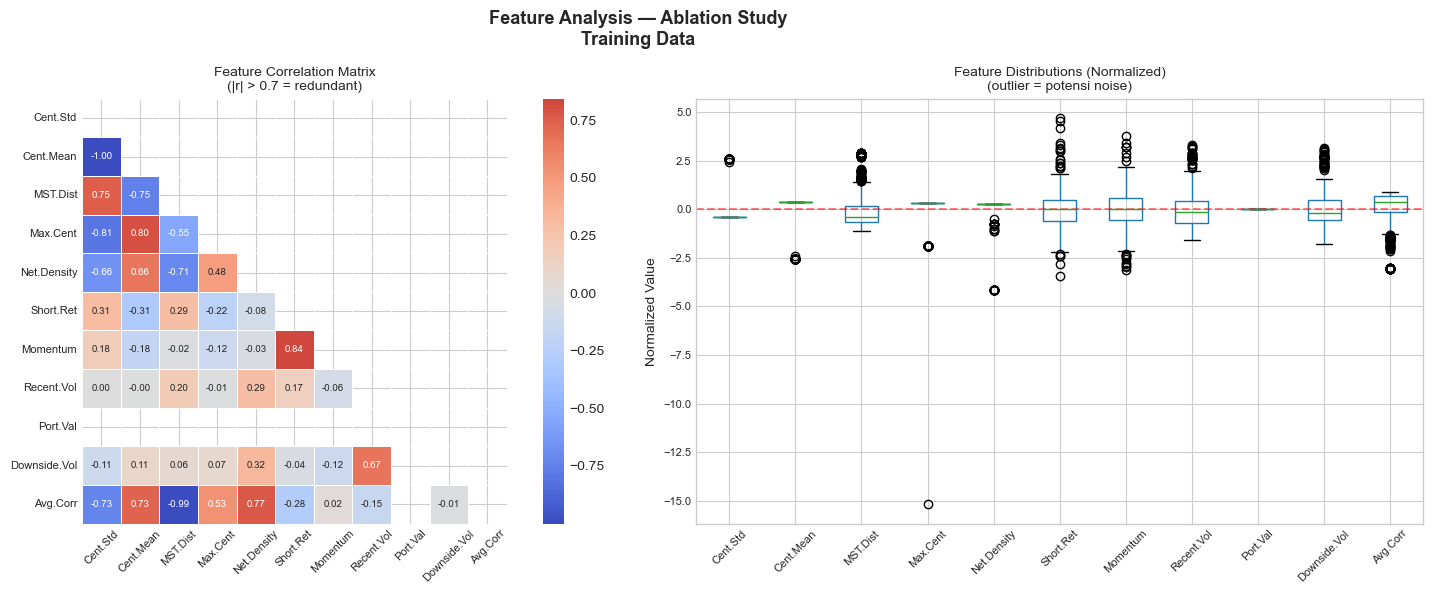


High-correlation pairs (|r| > 0.6):
  Cent.Std <-> Cent.Mean: r = -1.000
  Cent.Std <-> MST.Dist: r = 0.752
  Cent.Std <-> Max.Cent: r = -0.805
  Cent.Std <-> Net.Density: r = -0.657
  Cent.Std <-> Avg.Corr: r = -0.731
  Cent.Mean <-> MST.Dist: r = -0.752
  Cent.Mean <-> Max.Cent: r = 0.805
  Cent.Mean <-> Net.Density: r = 0.657
  Cent.Mean <-> Avg.Corr: r = 0.731
  MST.Dist <-> Net.Density: r = -0.714
  MST.Dist <-> Avg.Corr: r = -0.991
  Net.Density <-> Avg.Corr: r = 0.774
  Short.Ret <-> Momentum: r = 0.843
  Recent.Vol <-> Downside.Vol: r = 0.665


In [6]:
# Kumpulkan semua fitur dari training data (menggunakan config E5_AddBoth — terlengkap)
all_features = []

print('Collecting features for correlation analysis...')
for i in range(SET_WINDOW, len(ret_train)):
    win = ret_train.iloc[i - SET_WINDOW : i]
    nw, corr_f, _ = compute_network_features(win)
    mkt   = compute_market_features(win)
    extra = compute_extra_features(win, corr_f, ['downside_vol', 'avg_corr'])
    all_features.append(np.concatenate([nw, mkt, extra]))

feat_names = [
    'Cent.Std', 'Cent.Mean', 'MST.Dist', 'Max.Cent', 'Net.Density',
    'Short.Ret', 'Momentum', 'Recent.Vol', 'Port.Val',
    'Downside.Vol', 'Avg.Corr'
]

df_feat = pd.DataFrame(all_features, columns=feat_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis — Ablation Study\nTraining Data', fontsize=13, fontweight='bold')

# Heatmap korelasi
ax1 = axes[0]
corr_matrix = df_feat.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax1, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            annot_kws={'size': 7})
ax1.set_title('Feature Correlation Matrix\n(|r| > 0.7 = redundant)', fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)

# Distribusi fitur (boxplot, normalized)
ax2 = axes[1]
df_normalized = (df_feat - df_feat.mean()) / (df_feat.std() + 1e-8)
df_normalized.boxplot(ax=ax2, rot=45, fontsize=8)
ax2.set_title('Feature Distributions (Normalized)\n(outlier = potensi noise)', fontsize=10)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Normalized Value')

plt.tight_layout()
plt.savefig('ablation_results_calmar/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print pasangan fitur yang berkorelasi tinggi
print('\nHigh-correlation pairs (|r| > 0.6):')
found = False
for i in range(len(feat_names)):
    for j in range(i + 1, len(feat_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f'  {feat_names[i]} <-> {feat_names[j]}: r = {r:.3f}')
            found = True
if not found:
    print('  (Tidak ada pasangan dengan |r| > 0.6)')


## Calmar Reward — Penjelasan

**Formula:**
```
Calmar Ratio = Annualized Return (CAGR) / |Max Drawdown|
```

**Cara kerja di environment ini:**
- Setiap step, agent menerima reward berupa **running Calmar Ratio** sejak awal episode
- `ann_ret` dihitung dari kumulatif return yang sudah terjadi, di-annualize ke 252 hari
- `max_drawdown` adalah drawdown terbesar (paling negatif) yang pernah terjadi di episode
- Jika belum ada drawdown, reward = `ann_ret × 10` (proporsional, tidak dibagi nol)
- Raw reward kemudian dinormalisasi dengan **Welford online algorithm** agar skala stabil

**Keunggulan vs Pure Return:**
| Aspek | Pure Return | Calmar Reward |
|-------|------------|---------------|
| Sensitivitas crash | ❌ Tidak | ✅ Ya |
| Risk-aware | ❌ Tidak | ✅ Ya |
| Cocok kripto | Sedang | Lebih baik |
| Interpretabilitas | Tinggi | Sedang |

> **Catatan:** Calmar mendorong agent menghindari drawdown besar meski return tinggi.
> Agent akan prefer steady growth daripada profit besar tapi volatile.


## Phase 5: Ablation Environment

In [7]:
def precompute_ablation_data(returns_data, config, window_size=30):
    """Precompute obs cache untuk satu ablation config."""
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    n_steps = len(returns_data) - window_size
    print(f'  Precomputing {n_steps} steps...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape

        obs, corr_f, cent_vec = build_observation(win, config, port_val=0.0)
        obs_cache[i] = obs

        sigma = win.std().values
        mu    = win.mean().values
        cov_f = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        opt_cache[i] = (cov_f, cent_vec, mu)

        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)

    print(f'  Done! obs_dim={len(obs_cache[window_size])}')
    return obs_cache, opt_cache, baseline_ret_cache


class AblationPortfolioEnv(gym.Env):
    """
    Environment untuk ablation study.
    Reward: Calmar Ratio = Ann.Return / |Max Drawdown|, dinormalisasi secara online
            menggunakan Welford running mean/std agar skala stabil lintas episode.
    Agent didorong memaksimalkan return relatif terhadap drawdown terbesar (risk-aware).
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache, config,
                 window_size=30, gamma_center=1.0):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache
        self.config             = config
        self.window_size        = window_size
        self.gamma_center       = gamma_center
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        self._max_drawdown      = 0.0   # tracking max drawdown sejak episode dimulai
        self._episode_returns   = []    # buffer return harian untuk ann. return
        # Welford running stats untuk normalisasi reward
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0

        obs_dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)

    def _get_obs(self):
        obs = self.obs_cache[self.current_step].copy()
        # Update port_val slot di market features (F9)
        if self.config['use_market']:
            offset = 5 if self.config['use_network'] else 0
            if offset + 3 < len(obs):
                obs[offset + 3] = self.port_val - 1.0
        return obs

    def _normalize_reward(self, r):
        """Welford online normalisasi reward."""
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return float(np.clip(r / std, -10.0, 10.0))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = self.window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._max_drawdown   = 0.0
        self._episode_returns = []
        self._rew_mean       = 0.0
        self._rew_M2         = 0.0
        self._rew_count      = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        self._episode_returns.append(port_ret)

        # ── Calmar Ratio Reward ──────────────────────────────────────────
        # Calmar = Annualized Return / |Max Drawdown|
        # Dihitung secara running (episode kumulatif) & dinormalisasi Welford
        drawdown = (self.port_val - self.peak_val) / (self.peak_val + 1e-8)
        self._max_drawdown = min(self._max_drawdown, drawdown)  # tracking min (most negative)

        arr = np.array(self._episode_returns)
        n   = len(arr)
        total_growth = (1 + arr).prod()
        ann_ret = total_growth ** (252.0 / n) - 1 if total_growth > 0 else -1.0

        abs_max_dd = abs(self._max_drawdown)
        if abs_max_dd < 1e-6:
            # Belum ada drawdown — beri reward kecil proporsional dengan ann_ret
            raw_reward = ann_ret * 10
        else:
            calmar     = ann_ret / abs_max_dd
            raw_reward = float(np.clip(calmar, -20.0, 20.0))

        reward = self._normalize_reward(raw_reward)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, reward, done, False, {}


print('AblationPortfolioEnv defined.')


AblationPortfolioEnv defined.


## Phase 6: Backtest Engine & Strategy Classes

In [8]:
class AblationStrategy:
    """SAC strategy dengan ablation config tertentu. Mendukung static gamma benchmark."""
    def __init__(self, name, model_path, config, gamma_center=1.0):
        self.name         = name
        self.config       = config
        self.gamma_center = gamma_center
        self.is_static    = config.get('static_gamma') is not None

        if self.is_static:
            self.model      = None
            self.last_gamma = config['static_gamma']
        else:
            self.model      = SAC.load(model_path)
            self.last_gamma = gamma_center

    def compute_weights(self, returns_window, port_val=1.0):
        if self.is_static:
            self.last_gamma = self.config['static_gamma']
            return get_centrality_weights(returns_window, gamma=self.last_gamma)

        obs, _, _ = build_observation(returns_window, self.config,
                                                   port_val=port_val - 1.0)
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7):
    """Jalankan backtest walk-forward dengan rebalancing periodik. Tracks portfolio value."""
    rets, dates, gamma_history = [], [], []
    current_weights = None
    current_gamma   = 1.0
    port_val        = 1.0   # track cumulative portfolio value
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i - window : i]
            # Pass live port_val so market feature F9 is realistic
            if hasattr(strategy, 'is_static') and strategy.is_static:
                current_weights = strategy.compute_weights(window_df)
            else:
                current_weights = strategy.compute_weights(window_df, port_val=port_val)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
            gamma_history.append(current_gamma)
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history, index=dates))


print('Backtest engine defined.')


Backtest engine defined.


## Phase 7: Training — Semua Ablation Configs

Melatih SAC untuk setiap kombinasi fitur × seed.

In [9]:
sac_kwargs = {
    'policy'         : 'MlpPolicy',
    'learning_rate'  : 3e-4,
    'buffer_size'    : 50000,
    'batch_size'     : 256,
    'ent_coef'       : 'auto',
    'train_freq'     : 1,
    'gradient_steps' : 1,
    'learning_starts': 200,   # was 1000; reduced so SAC trains within TRAIN_STEPS
    'tau'            : 0.005,
    'gamma'          : 0.99,
}

trained_model_paths = {}  # {(exp_id, seed): model_path}

sep = '=' * 60
for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\n{sep}')
    print(f'Experiment: {exp_id} | obs_dim={get_obs_dim(config)}')
    print(f'  Network: {config["use_network"]} | Market: {config["use_market"]} | Extra: {config["extra_features"]}')
    print('Precomputing data...')

    obs_cache, opt_cache, baseline_ret_cache = precompute_ablation_data(
        ret_train, config, window_size=SET_WINDOW
    )

    for seed in SEEDS:
        model_name = f'ablation_{exp_id}_seed{seed}'

        if config.get('static_gamma') is not None:
            if seed == SEEDS[0]:
                print(f'  Static benchmark {exp_id} — tidak perlu training.')
            trained_model_paths[(exp_id, seed)] = 'static'
            continue

        print(f'  Training seed={seed}...')

        env = AblationPortfolioEnv(
            ret_train, obs_cache, opt_cache, baseline_ret_cache, config,
            window_size=SET_WINDOW,
            gamma_center=GAMMA_CENTER,
        )

        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)
        trained_model_paths[(exp_id, seed)] = model_name
        print(f'    Saved: {model_name}.zip')

print('\n=== Semua model ablation selesai dilatih ===')



Experiment: E0_Baseline | obs_dim=9
  Network: True | Market: True | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=9
  Training seed=42...


Output()

Output()

    Saved: ablation_E0_Baseline_seed42.zip
  Training seed=123...


Output()

...

Output()

    Saved: ablation_E5_AddBoth_seed42.zip
  Training seed=123...


Output()

    Saved: ablation_E5_AddBoth_seed123.zip
  Training seed=77...


    Saved: ablation_E5_AddBoth_seed77.zip

Experiment: Comp_Static_Gamma0 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma0 — tidak perlu training.

Experiment: Comp_Static_Gamma1 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma1 — tidak perlu training.

Experiment: Comp_Static_Gamma2 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma2 — tidak perlu training.

=== Semua model ablation selesai dilatih ===


## Phase 8: Backtest — Training & Testing Data

In [10]:
# ================================================================
# Jalankan backtest untuk semua eksperimen & kedua periode
# ================================================================

ablation_results = {}  # {exp_id: {'train': {seed: ret_series}, 'test': {seed: ret_series}}}

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\nBacktest: {exp_id}')
    ablation_results[exp_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(exp_id, seed)]

        strat_tr = AblationStrategy(f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER)
        ret_tr, _ = run_backtest(strat_tr, ret_train, SET_WINDOW, SET_REBALANCE)
        ablation_results[exp_id]['train'][seed] = ret_tr

        strat_te = AblationStrategy(f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER)
        ret_te, _ = run_backtest(strat_te, ret_test, SET_WINDOW, SET_REBALANCE)
        ablation_results[exp_id]['test'][seed] = ret_te

        tr_total = calculate_total_return(ret_tr)
        te_total = calculate_total_return(ret_te)
        print(f'  seed={seed} | Train TotalRet: {tr_total:.4f} | Test TotalRet: {te_total:.4f}')

print('\nSemua backtest selesai.')



Backtest: E0_Baseline
  seed=42 | Train TotalRet: -0.6224 | Test TotalRet: -0.0791
  seed=123 | Train TotalRet: -0.6141 | Test TotalRet: -0.0791
  seed=77 | Train TotalRet: -0.6225 | Test TotalRet: -0.0791

Backtest: E1_NoNetwork
  seed=42 | Train TotalRet: -0.6100 | Test TotalRet: -0.0791
  seed=123 | Train TotalRet: -0.6227 | Test TotalRet: -0.0791
  seed=77 | Train TotalRet: -0.6410 | Test TotalRet: -0.0791

Backtest: E2_NoMarket
  seed=42 | Train TotalRet: -0.6231 | Test TotalRet: -0.0791
  seed=123 | Train TotalRet: -0.6228 | Test TotalRet: -0.0791
  seed=77 | Train TotalRet: -0.6226 | Test TotalRet: -0.0791

Backtest: E3_AddDownside
  seed=42 | Train TotalRet: -0.6228 | Test TotalRet: -0.0791
  seed=123 | Train TotalRet: -0.6246 | Test TotalRet: -0.0791
  seed=77 | Train TotalRet: -0.6223 | Test TotalRet: -0.0791

Backtest: E4_AddAvgCorr
  seed=42 | Train TotalRet: -0.6222 | Test TotalRet: -0.0791
  seed=123 | Train TotalRet: -0.4661 | Test TotalRet: -0.0791
  seed=77 | Train To

## Phase 9: Hasil Ablation Study (Return-based)

In [11]:
# ================================================================
# Agregasi hasil: Mean +/- Std Total Return & Annualized Return
# ================================================================

summary_rows = []

for exp_id, config in ABLATION_CONFIGS.items():
    train_total = [calculate_total_return(ablation_results[exp_id]['train'][s]) for s in SEEDS]
    test_total  = [calculate_total_return(ablation_results[exp_id]['test'][s])  for s in SEEDS]
    train_ann   = [calculate_annualized_return(ablation_results[exp_id]['train'][s]) for s in SEEDS]
    test_ann    = [calculate_annualized_return(ablation_results[exp_id]['test'][s])  for s in SEEDS]

    # Metrik tambahan dari mean return lintas seed
    mean_train_ret = pd.concat([ablation_results[exp_id]['train'][s] for s in SEEDS], axis=1).mean(axis=1)
    mean_test_ret  = pd.concat([ablation_results[exp_id]['test'][s]  for s in SEEDS], axis=1).mean(axis=1)
    train_m = calculate_metrics(mean_train_ret)
    test_m  = calculate_metrics(mean_test_ret)

    obs_dim = get_obs_dim(config)
    feature_desc = []
    if config.get('static_gamma') is not None:
        feature_desc.append(f'Static Gamma {config["static_gamma"]}')
    else:
        if config['use_network']: feature_desc.append('Network(5)')
        if config['use_market']:  feature_desc.append('Market(4)')
        for e in config['extra_features']: feature_desc.append(e)

    summary_rows.append({
        'Experiment'              : exp_id,
        'Features'                : ' + '.join(feature_desc),
        'Obs Dim'                 : obs_dim,
        # Training
        'TotalRet Train (mean)'   : np.mean(train_total),
        'TotalRet Train (std)'    : np.std(train_total),
        'AnnRet Train (mean)'     : np.mean(train_ann),
        'AnnRet Train (std)'      : np.std(train_ann),
        'Sharpe Train'            : train_m['Sharpe Ratio'],
        'MaxDD Train'             : train_m['Max Drawdown'],
        # Testing
        'TotalRet Test (mean)'    : np.mean(test_total),
        'TotalRet Test (std)'     : np.std(test_total),
        'AnnRet Test (mean)'      : np.mean(test_ann),
        'AnnRet Test (std)'       : np.std(test_ann),
        'Sharpe Test'             : test_m['Sharpe Ratio'],
        'MaxDD Test'              : test_m['Max Drawdown'],
        # Generalization gap
        'TotalRet Gap'            : np.mean(train_total) - np.mean(test_total),
        'AnnRet Gap'              : np.mean(train_ann)   - np.mean(test_ann),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')
summary_df.to_csv('ablation_results_calmar/ablation_summary_calmar.csv')

sep = '=' * 70
print(sep)
print('ABLATION STUDY RESULTS — TOTAL & ANNUALIZED RETURN (Mean +/- Std across seeds)')
print(sep)
print(summary_df[[
    'Features', 'Obs Dim',
    'TotalRet Train (mean)', 'TotalRet Train (std)',
    'TotalRet Test (mean)',  'TotalRet Test (std)',
    'AnnRet Test (mean)',    'AnnRet Test (std)',
    'TotalRet Gap'
]].round(4).to_string())
print(sep)

# Ranking berdasarkan Annualized Return Testing
ranked = summary_df.sort_values('AnnRet Test (mean)', ascending=False)
print('\nRANKING (by Annualized Return — Testing):')
for rank, (exp_id, row) in enumerate(ranked.iterrows(), 1):
    print(f'  #{rank} {exp_id}: AnnRet Test = {row["AnnRet Test (mean)"]:.4f} +/- {row["AnnRet Test (std)"]:.4f}')


ABLATION STUDY RESULTS — TOTAL & ANNUALIZED RETURN (Mean +/- Std across seeds)
                                                            Features  Obs Dim  TotalRet Train (mean)  TotalRet Train (std)  TotalRet Test (mean)  TotalRet Test (std)  AnnRet Test (mean)  AnnRet Test (std)  TotalRet Gap
Experiment                                                                                                                                                                                                                
E0_Baseline                                   Network(5) + Market(4)        9                -0.6196                0.0039               -0.0791                  0.0             -0.0991                0.0       -0.5405
E1_NoNetwork                                               Market(4)        4                -0.6245                0.0127               -0.0791                  0.0             -0.0991                0.0       -0.5454
E2_NoMarket                                  

## Phase 10: Visualisasi Ablation Study

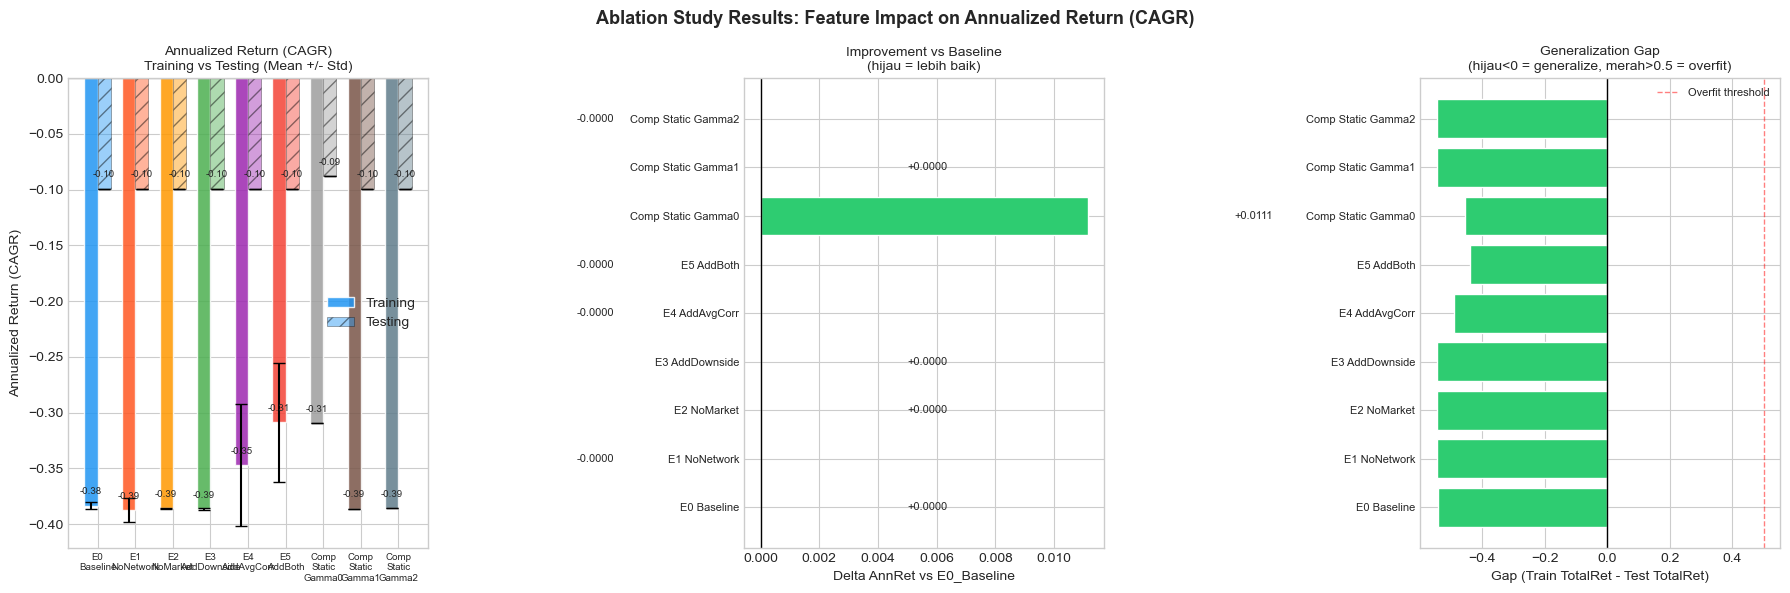

Saved: ablation_results_calmar/ablation_return_comparison.png


In [12]:
# ================================================================
# VISUALISASI 1: Grouped Bar Chart — AnnRet Train vs Test
# ================================================================

exp_ids     = list(ABLATION_CONFIGS.keys())
train_means = summary_df.loc[exp_ids, 'AnnRet Train (mean)'].values
train_stds  = summary_df.loc[exp_ids, 'AnnRet Train (std)'].values
test_means  = summary_df.loc[exp_ids, 'AnnRet Test (mean)'].values
test_stds   = summary_df.loc[exp_ids, 'AnnRet Test (std)'].values

x     = np.arange(len(exp_ids))
width = 0.35

ABLATION_COLORS = {
    'E0_Baseline'        : '#2196F3',
    'E1_NoNetwork'       : '#FF5722',
    'E2_NoMarket'        : '#FF9800',
    'E3_AddDownside'     : '#4CAF50',
    'E4_AddAvgCorr'      : '#9C27B0',
    'E5_AddBoth'         : '#F44336',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
}
colors = [ABLATION_COLORS[e] for e in exp_ids]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Ablation Study Results: Feature Impact on Annualized Return (CAGR)',
             fontsize=13, fontweight='bold')

# --- Panel 1: Grouped Bar ---
ax = axes[0]
bars1 = ax.bar(x - width/2, train_means, width, yerr=train_stds,
               label='Training', color=colors, alpha=0.85, capsize=4, edgecolor='white')
bars2 = ax.bar(x + width/2, test_means, width, yerr=test_stds,
               label='Testing', color=colors, alpha=0.45, capsize=4,
               edgecolor='black', linewidth=0.5, hatch='//')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([e.replace('_', '\n') for e in exp_ids], fontsize=7)
ax.set_ylabel('Annualized Return (CAGR)')
ax.set_title('Annualized Return (CAGR)\nTraining vs Testing (Mean +/- Std)', fontsize=10)
ax.legend()
for b, v in zip(bars1, train_means):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f'{v:.2f}', ha='center', fontsize=7)
for b, v in zip(bars2, test_means):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f'{v:.2f}', ha='center', fontsize=7)

# --- Panel 2: Delta AnnRet vs Baseline (E0) ---
ax2 = axes[1]
baseline_test = summary_df.loc['E0_Baseline', 'AnnRet Test (mean)']
deltas = test_means - baseline_test
delta_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]
bars3 = ax2.barh([e.replace('_', ' ') for e in exp_ids], deltas,
                 color=delta_colors, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('Delta AnnRet vs E0_Baseline')
ax2.set_title('Improvement vs Baseline\n(hijau = lebih baik)', fontsize=10)
ax2.tick_params(axis='y', labelsize=8)
for bar, d in zip(bars3, deltas):
    ax2.text(d + (0.005 if d >= 0 else -0.005),
             bar.get_y() + bar.get_height() / 2,
             f'{d:+.4f}', va='center',
             ha='left' if d >= 0 else 'right', fontsize=8)

# --- Panel 3: Overfitting Gap (TotalRet Train - Test) ---
ax3 = axes[2]
gaps = summary_df.loc[exp_ids, 'TotalRet Gap'].values
gap_colors = ['#e74c3c' if g > 0.5 else '#2ecc71' if g < 0 else '#f39c12' for g in gaps]
bars4 = ax3.barh([e.replace('_', ' ') for e in exp_ids], gaps,
                 color=gap_colors, edgecolor='white')
ax3.axvline(0, color='black', linewidth=1)
ax3.axvline(0.5, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Overfit threshold')
ax3.set_xlabel('Gap (Train TotalRet - Test TotalRet)')
ax3.set_title('Generalization Gap\n(hijau<0 = generalize, merah>0.5 = overfit)', fontsize=10)
ax3.tick_params(axis='y', labelsize=8)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ablation_results_calmar/ablation_return_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_calmar/ablation_return_comparison.png')


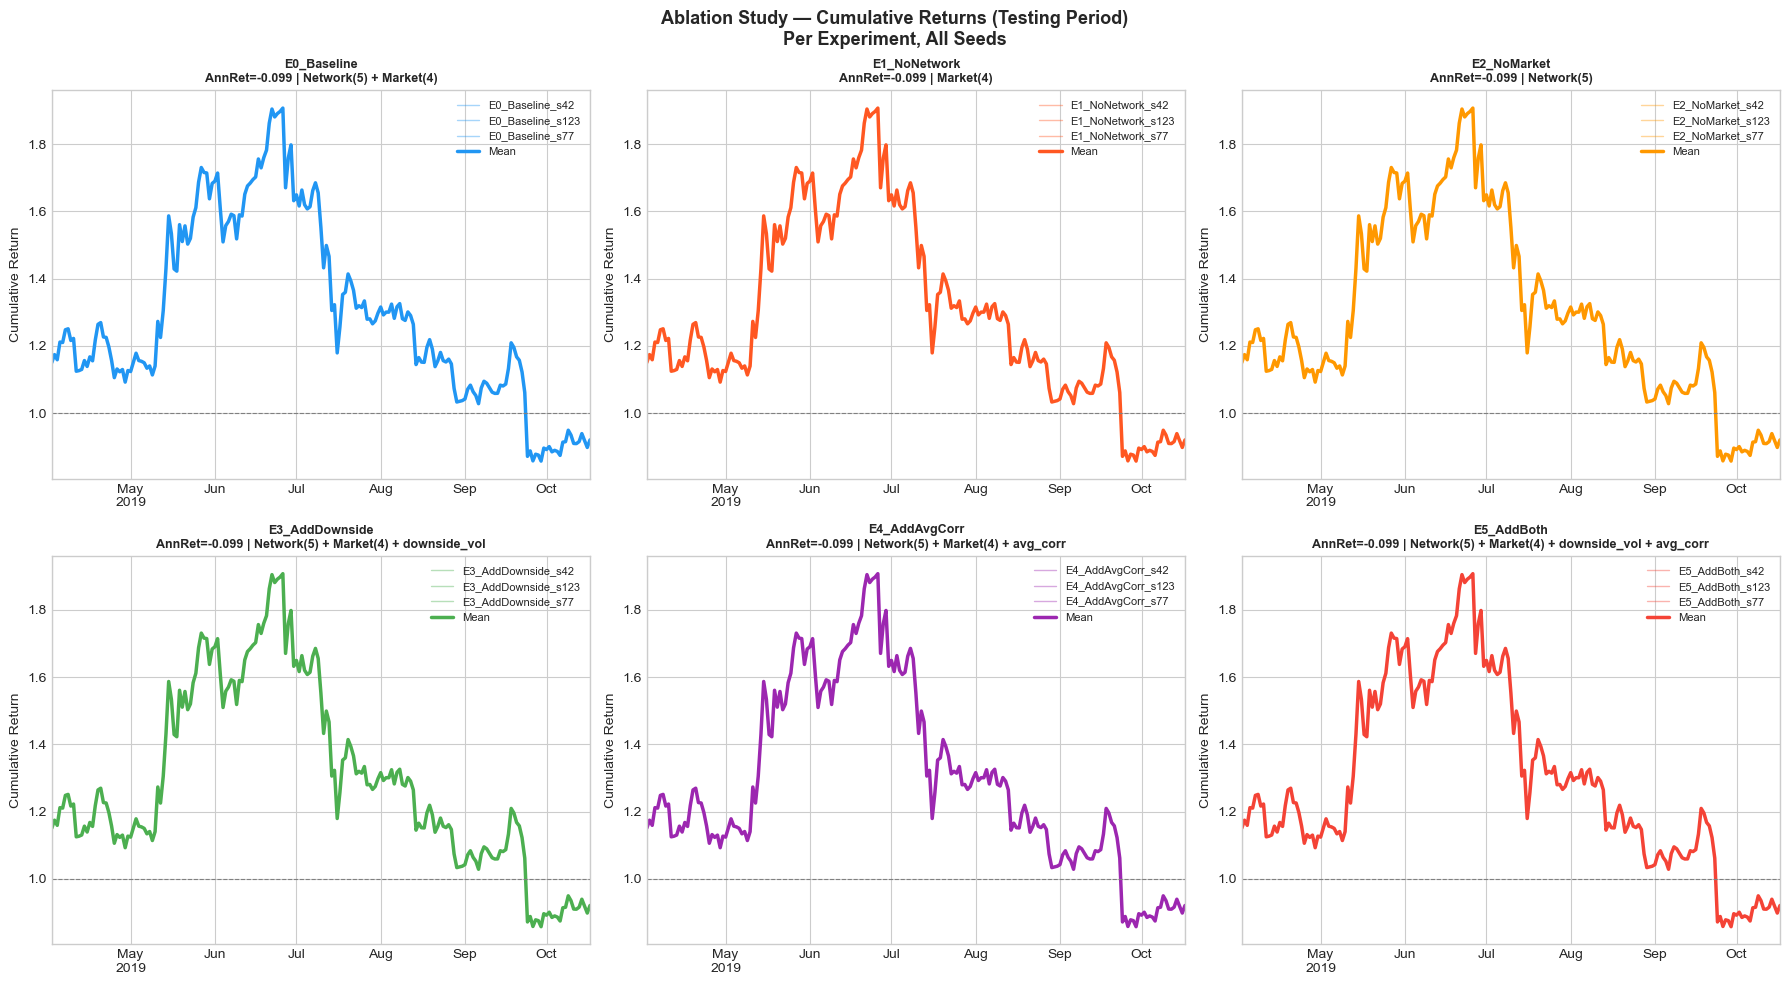

Saved: ablation_results_calmar/ablation_cumret_testing.png


In [13]:
# ================================================================
# VISUALISASI 2: Cumulative Returns semua eksperimen (Testing)
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Ablation Study — Cumulative Returns (Testing Period)\nPer Experiment, All Seeds',
             fontsize=13, fontweight='bold')

for ax, (exp_id, config) in zip(axes.flatten(), ABLATION_CONFIGS.items()):
    color = ABLATION_COLORS[exp_id]
    seed_rets = []
    for seed in SEEDS:
        ret = ablation_results[exp_id]['test'][seed]
        cum = (1 + ret).cumprod()
        cum.plot(ax=ax, alpha=0.4, color=color, linewidth=1)
        seed_rets.append(cum)

    mean_cum = pd.concat(seed_rets, axis=1).mean(axis=1)
    mean_cum.plot(ax=ax, color=color, linewidth=2.5, label='Mean')

    annret_test = summary_df.loc[exp_id, 'AnnRet Test (mean)']
    feat_desc   = summary_df.loc[exp_id, 'Features']
    ax.set_title(f'{exp_id}\nAnnRet={annret_test:.3f} | {feat_desc}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Cumulative Return')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ablation_results_calmar/ablation_cumret_testing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_calmar/ablation_cumret_testing.png')


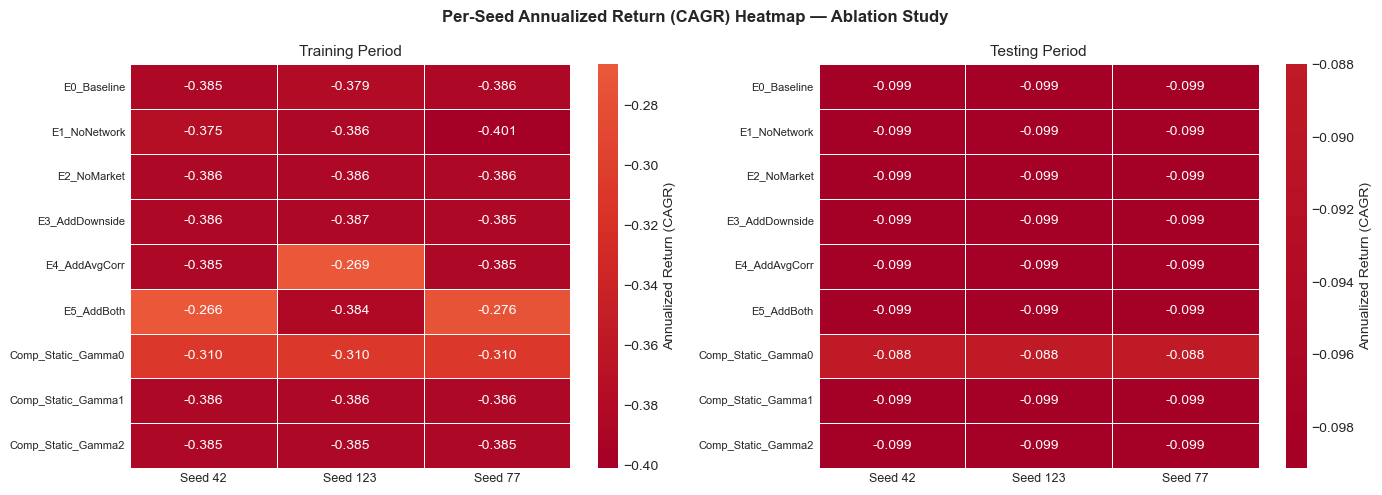

Saved: ablation_results_calmar/ablation_heatmap_perseed.png


In [14]:
# ================================================================
# VISUALISASI 3: Per-Seed Annualized Return Heatmap
# ================================================================

heatmap_train = pd.DataFrame(index=exp_ids, columns=[f'Seed {s}' for s in SEEDS], dtype=float)
heatmap_test  = pd.DataFrame(index=exp_ids, columns=[f'Seed {s}' for s in SEEDS], dtype=float)

for exp_id in exp_ids:
    for seed in SEEDS:
        heatmap_train.loc[exp_id, f'Seed {seed}'] = calculate_annualized_return(
            ablation_results[exp_id]['train'][seed])
        heatmap_test.loc[exp_id, f'Seed {seed}'] = calculate_annualized_return(
            ablation_results[exp_id]['test'][seed])

# Ganti NaN dengan 0 untuk visualisasi (NaN muncul jika portfolio value <= 0)
heatmap_train = heatmap_train.fillna(0).astype(float)
heatmap_test  = heatmap_test.fillna(0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Seed Annualized Return (CAGR) Heatmap — Ablation Study',
             fontsize=12, fontweight='bold')

for ax, hm, title in zip(axes,
                          [heatmap_train, heatmap_test],
                          ['Training Period', 'Testing Period']):
    sns.heatmap(hm, ax=ax, annot=True, fmt='.3f',
                cmap='RdYlGn', center=0, linewidths=0.5,
                cbar_kws={'label': 'Annualized Return (CAGR)'})
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

plt.tight_layout()
plt.savefig('ablation_results_calmar/ablation_heatmap_perseed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_calmar/ablation_heatmap_perseed.png')


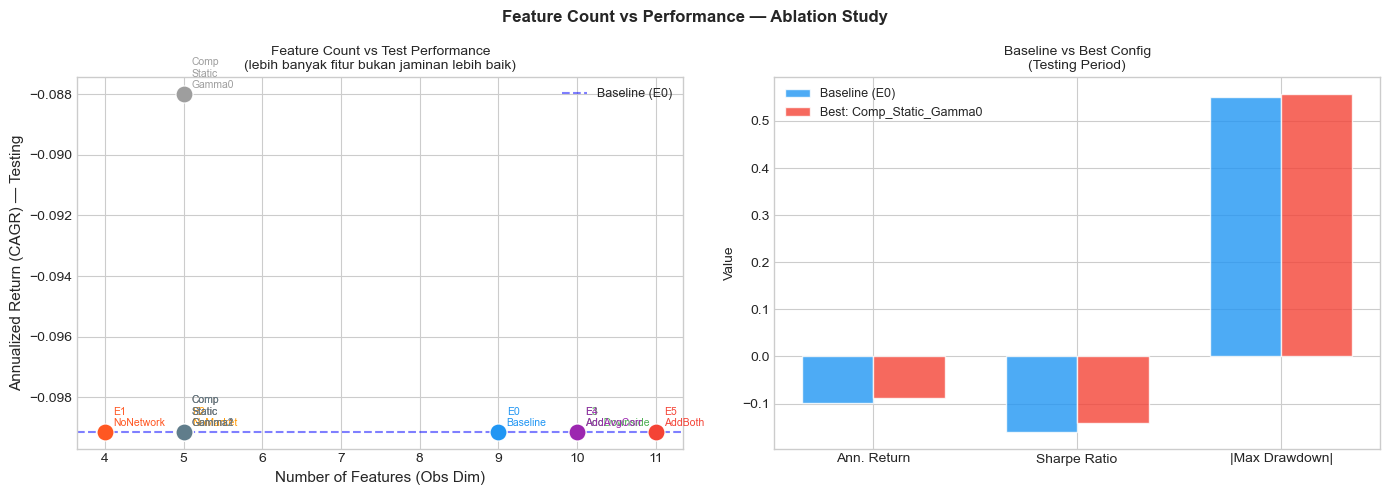

Saved: ablation_results_calmar/ablation_feature_count_vs_perf.png


In [15]:
# ================================================================
# VISUALISASI 4: Scatter — Obs Dim vs AnnRet Test
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Count vs Performance — Ablation Study', fontsize=12, fontweight='bold')

obs_dims     = summary_df['Obs Dim'].values
annret_tests = summary_df['AnnRet Test (mean)'].values
annret_stds  = summary_df['AnnRet Test (std)'].values

ax1 = axes[0]
for i, exp_id in enumerate(exp_ids):
    ax1.scatter(obs_dims[i], annret_tests[i], s=150,
                color=ABLATION_COLORS[exp_id], zorder=5, edgecolor='white', linewidth=0.8)
    ax1.annotate(exp_id.replace('_', '\n'), (obs_dims[i], annret_tests[i]),
                 textcoords='offset points', xytext=(6, 4), fontsize=7.5,
                 color=ABLATION_COLORS[exp_id])
    ax1.errorbar(obs_dims[i], annret_tests[i], yerr=annret_stds[i],
                 fmt='none', color=ABLATION_COLORS[exp_id], capsize=4, alpha=0.5)

ax1.set_xlabel('Number of Features (Obs Dim)', fontsize=11)
ax1.set_ylabel('Annualized Return (CAGR) — Testing', fontsize=11)
ax1.set_title('Feature Count vs Test Performance\n(lebih banyak fitur bukan jaminan lebih baik)', fontsize=10)
ax1.axhline(summary_df.loc['E0_Baseline', 'AnnRet Test (mean)'],
            color='blue', linestyle='--', alpha=0.5, label='Baseline (E0)')
ax1.legend(fontsize=9)

# Bar: metrik perbandingan E0 vs best config
ax2 = axes[1]
best_exp = summary_df.sort_values('AnnRet Test (mean)', ascending=False).index[0]

bar_width = 0.35
metric_labels = ['Ann. Return', 'Sharpe Ratio', '|Max Drawdown|']
for offset, (exp_id, label, color) in enumerate([
    ('E0_Baseline', 'Baseline (E0)', '#2196F3'),
    (best_exp, f'Best: {best_exp}', '#F44336')
]):
    mean_ret = pd.concat(
        [ablation_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    m = calculate_metrics(mean_ret)
    vals = [m['Ann. Return'], m['Sharpe Ratio'], abs(m['Max Drawdown'])]
    ax2.bar(np.arange(3) + offset * bar_width, vals, bar_width,
            label=label, color=color, alpha=0.8, edgecolor='white')

ax2.set_xticks(np.arange(3) + bar_width / 2)
ax2.set_xticklabels(metric_labels)
ax2.set_title(f'Baseline vs Best Config\n(Testing Period)', fontsize=10)
ax2.legend(fontsize=9)
ax2.set_ylabel('Value')

plt.tight_layout()
plt.savefig('ablation_results_calmar/ablation_feature_count_vs_perf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_calmar/ablation_feature_count_vs_perf.png')


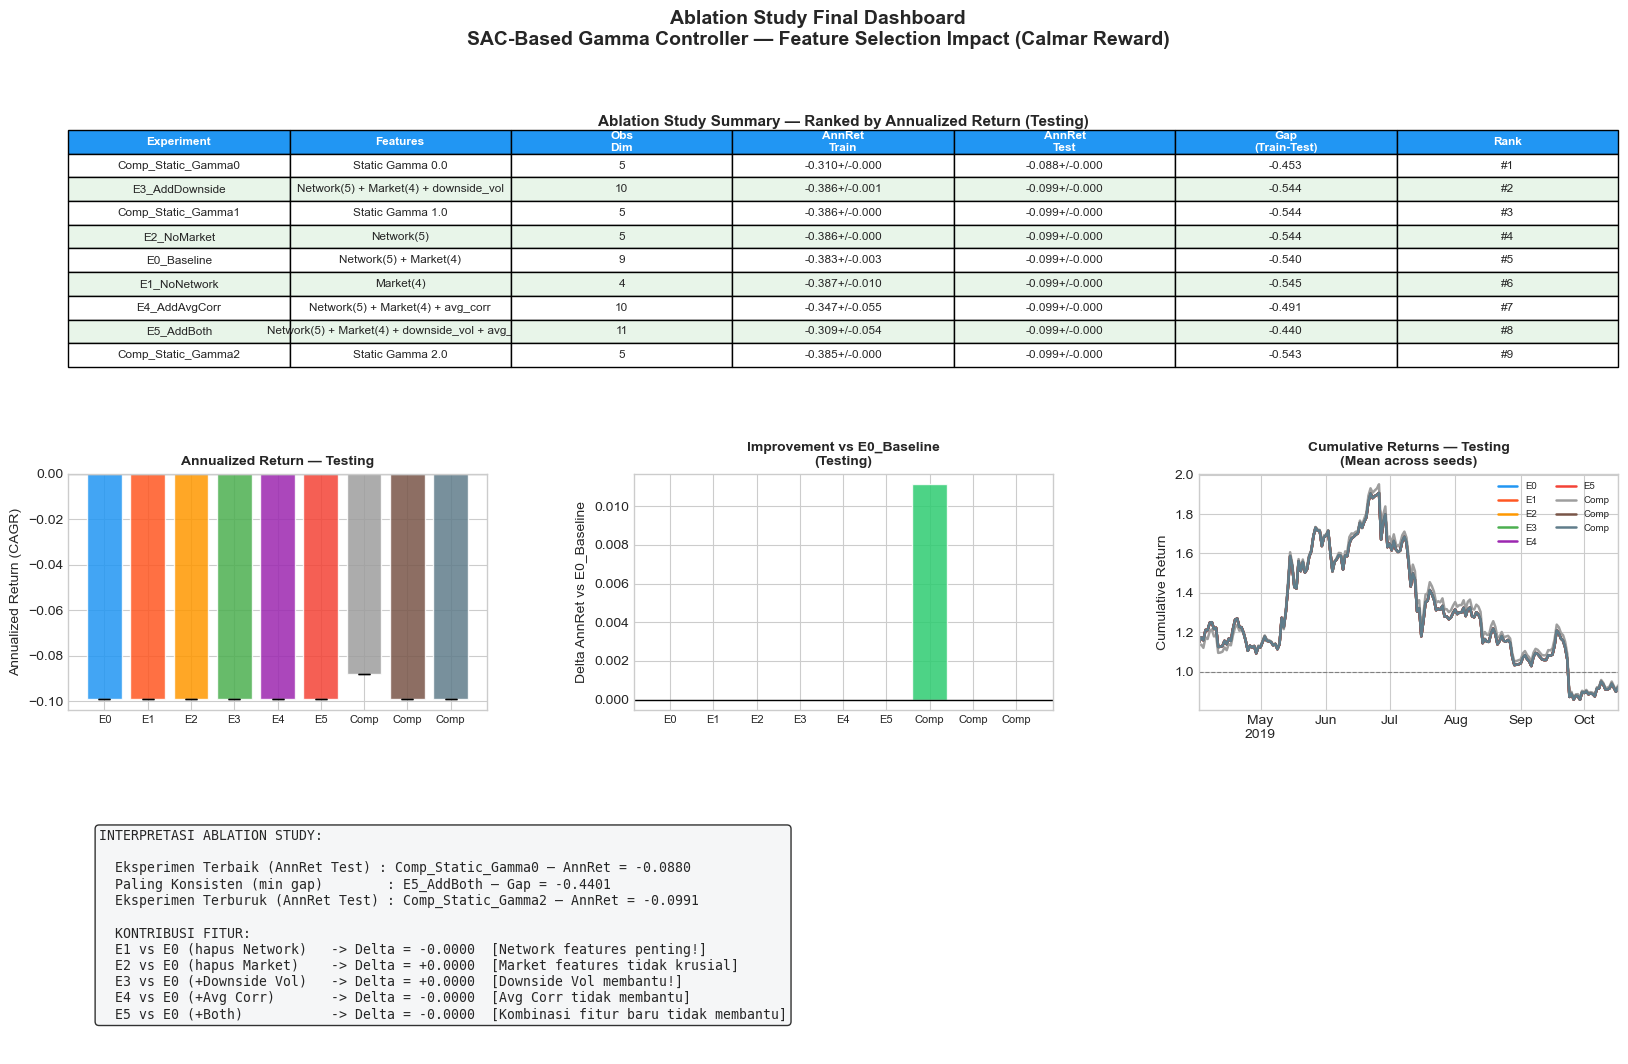


Ablation Study Complete!
Outputs saved to ablation_results_calmar/:
  - ablation_summary_calmar.csv
  - feature_correlation.png
  - ablation_return_comparison.png
  - ablation_cumret_testing.png
  - ablation_heatmap_perseed.png
  - ablation_feature_count_vs_perf.png
  - ablation_final_dashboard.png


In [16]:
# ================================================================
# VISUALISASI 5: Final Dashboard
# ================================================================

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Ablation Study Final Dashboard\nSAC-Based Gamma Controller — Feature Selection Impact (Calmar Reward)',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel 1: Summary Table ---
ax_tbl = fig.add_subplot(gs[0, :])
ax_tbl.axis('off')
tbl_data   = []
col_labels = ['Experiment', 'Features', 'Obs\nDim',
              'AnnRet\nTrain', 'AnnRet\nTest', 'Gap\n(Train-Test)', 'Rank']
ranked_df  = summary_df.sort_values('AnnRet Test (mean)', ascending=False)
for rank, (exp_id, row) in enumerate(ranked_df.iterrows(), 1):
    tbl_data.append([
        exp_id,
        row['Features'],
        int(row['Obs Dim']),
        f"{row['AnnRet Train (mean)']:.3f}+/-{row['AnnRet Train (std)']:.3f}",
        f"{row['AnnRet Test (mean)']:.3f}+/-{row['AnnRet Test (std)']:.3f}",
        f"{row['TotalRet Gap']:+.3f}",
        f'#{rank}'
    ])

tbl = ax_tbl.table(cellText=tbl_data, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2196F3')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, (exp_id, _) in enumerate(ranked_df.iterrows(), 1):
    fc = '#E8F5E9' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(fc)
ax_tbl.set_title('Ablation Study Summary — Ranked by Annualized Return (Testing)',
                 fontsize=11, fontweight='bold', pad=3)

# --- Panel 2: AnnRet Bar (Testing) ---
ax2 = fig.add_subplot(gs[1, 0])
exp_list  = list(summary_df.index)
test_vals = summary_df['AnnRet Test (mean)'].values
test_err  = summary_df['AnnRet Test (std)'].values
bcolors   = [ABLATION_COLORS[e] for e in exp_list]
ax2.bar(range(len(exp_list)), test_vals, yerr=test_err,
        color=bcolors, edgecolor='white', capsize=4, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(range(len(exp_list)))
ax2.set_xticklabels([e.split('_')[0] for e in exp_list], fontsize=8)
ax2.set_ylabel('Annualized Return (CAGR)')
ax2.set_title('Annualized Return — Testing', fontsize=10, fontweight='bold')

# --- Panel 3: Delta AnnRet vs E0 ---
ax3 = fig.add_subplot(gs[1, 1])
baseline_val = summary_df.loc['E0_Baseline', 'AnnRet Test (mean)']
deltas2 = test_vals - baseline_val
dc2 = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas2]
ax3.bar(range(len(exp_list)), deltas2, color=dc2, edgecolor='white', alpha=0.85)
ax3.axhline(0, color='black', linewidth=1)
ax3.set_xticks(range(len(exp_list)))
ax3.set_xticklabels([e.split('_')[0] for e in exp_list], fontsize=8)
ax3.set_ylabel('Delta AnnRet vs E0_Baseline')
ax3.set_title('Improvement vs E0_Baseline\n(Testing)', fontsize=10, fontweight='bold')

# --- Panel 4: Cumulative Returns (Testing, mean per exp) ---
ax4 = fig.add_subplot(gs[1, 2])
for exp_id in exp_ids:
    mean_ret = pd.concat(
        [ablation_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    (1 + mean_ret).cumprod().plot(
        ax=ax4, label=exp_id.split('_')[0],
        color=ABLATION_COLORS[exp_id], linewidth=1.8
    )
ax4.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax4.set_title('Cumulative Returns — Testing\n(Mean across seeds)', fontsize=10, fontweight='bold')
ax4.legend(fontsize=7, ncol=2)
ax4.set_ylabel('Cumulative Return')

# --- Panel 5: Interpretasi otomatis ---
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
best_test_exp  = ranked_df.index[0]
worst_test_exp = ranked_df.index[-1]
best_gap_exp   = summary_df['TotalRet Gap'].abs().idxmin()

e1_delta  = summary_df.loc['E1_NoNetwork', 'AnnRet Test (mean)'] - baseline_val
e2_delta  = summary_df.loc['E2_NoMarket',  'AnnRet Test (mean)'] - baseline_val
e3_delta  = summary_df.loc['E3_AddDownside','AnnRet Test (mean)'] - baseline_val
e4_delta  = summary_df.loc['E4_AddAvgCorr', 'AnnRet Test (mean)'] - baseline_val
e5_delta  = summary_df.loc['E5_AddBoth',    'AnnRet Test (mean)'] - baseline_val

interpretasi = (
    "INTERPRETASI ABLATION STUDY:\n\n"
    f"  Eksperimen Terbaik (AnnRet Test) : {best_test_exp}"
    f" — AnnRet = {summary_df.loc[best_test_exp, 'AnnRet Test (mean)']:.4f}\n"
    f"  Paling Konsisten (min gap)        : {best_gap_exp}"
    f" — Gap = {summary_df.loc[best_gap_exp, 'TotalRet Gap']:+.4f}\n"
    f"  Eksperimen Terburuk (AnnRet Test) : {worst_test_exp}"
    f" — AnnRet = {summary_df.loc[worst_test_exp, 'AnnRet Test (mean)']:.4f}\n\n"
    "  KONTRIBUSI FITUR:\n"
    f"  E1 vs E0 (hapus Network)   -> Delta = {e1_delta:+.4f}  "
    f"{'[Network features penting!]' if e1_delta < 0 else '[Network features tidak krusial]'}\n"
    f"  E2 vs E0 (hapus Market)    -> Delta = {e2_delta:+.4f}  "
    f"{'[Market features penting!]' if e2_delta < 0 else '[Market features tidak krusial]'}\n"
    f"  E3 vs E0 (+Downside Vol)   -> Delta = {e3_delta:+.4f}  "
    f"{'[Downside Vol membantu!]' if e3_delta > 0 else '[Downside Vol tidak membantu]'}\n"
    f"  E4 vs E0 (+Avg Corr)       -> Delta = {e4_delta:+.4f}  "
    f"{'[Avg Corr membantu!]' if e4_delta > 0 else '[Avg Corr tidak membantu]'}\n"
    f"  E5 vs E0 (+Both)           -> Delta = {e5_delta:+.4f}  "
    f"{'[Kedua fitur baru membantu!]' if e5_delta > 0 else '[Kombinasi fitur baru tidak membantu]'}"
)
ax5.text(0.02, 0.95, interpretasi, transform=ax5.transAxes,
         fontsize=9.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.8))

plt.savefig('ablation_results_calmar/ablation_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAblation Study Complete!')
print('Outputs saved to ablation_results_calmar/:')
print('  - ablation_summary_calmar.csv')
print('  - feature_correlation.png')
print('  - ablation_return_comparison.png')
print('  - ablation_cumret_testing.png')
print('  - ablation_heatmap_perseed.png')
print('  - ablation_feature_count_vs_perf.png')
print('  - ablation_final_dashboard.png')
